In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import pandas as pd
import ast
import numpy as np
from keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import Callback
from itertools import combinations
import random
import tensorflow.keras.backend as K
import os
#from common.utils import optimize_tf_gpu

2023-11-20 15:51:57.635849: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-11-20 15:51:57.637198: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-11-20 15:51:57.663571: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-11-20 15:51:57.664109: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-11-20 15:51:58.103037: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

In [2]:
GPU = True
if GPU:
    #tf.debugging.set_log_device_placement(True)
    #delegate = GpuDelegate()
    physical_devices = tf.config.list_physical_devices('GPU')
    print(physical_devices)
    #tf.config.experimental.set_memory_growth(physical_devices[0], True)
    #import os
    os.environ["CUDA_VISIBLE_DEVICES"]="0,1,2,3"
    os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
    #optimize_tf_gpu(tf, K)

[]


In [3]:
one_two_layers_file='df2.csv'
three_layers_file='df3.csv'
MC_file = 'df_MontCarlo.csv'

In [4]:
# Function to convert string tuple to tuple type tuple
def convert_to_tuple(str_tuple):
    try:
        return tuple(ast.literal_eval(str_tuple))
    except (ValueError, SyntaxError):
        # handle malformed tuples
        return None

In [5]:
# Function to convert tuples to binary vectors
def tuple_to_vector(t, length=75):
    v = np.zeros(length, dtype=int)
    v[np.array(t)] = 1  # Set indices present in tuple t to 1
    return v

In [6]:
# Load data for on and two arbitrary layers
df2=pd.read_csv(one_two_layers_file,index_col=0)
df2['name'] = df2['name'].apply(convert_to_tuple)

# Load data for on and two arbitrary layers
df3=pd.read_csv(three_layers_file,index_col=0)
df3['name'] = df3['name'].apply(convert_to_tuple)

# Load data for on and two arbitrary layers
df_mc=pd.read_csv(MC_file,index_col=0)
df_mc['name'] = df_mc['name'].apply(convert_to_tuple)

In [7]:
# Initialize a matrix with NaN values
max_j = 74  # This should be your maximum j value
matrix = np.full((75, max_j + 1), np.nan)

# Loop through i values
for i in range(75):
    
    # Set the i-th column value for cases where 'name' is (i,)
    val_i = df2.loc[df2['name'] == (i,), 'mAP']
    if not val_i.empty:
        matrix[i, i] = val_i.values[0]
    
    # Loop through j values
    for j in range(max_j + 1):
        
        # Set the j-th column value for cases where 'name' is (i, j) or (j, i)
        val_ij = df2.loc[(df2['name'] == (i, j)) | (df2['name'] == (j, i)), 'mAP']
        if not val_ij.empty:
            matrix[i, j] = val_ij.values[0]

def attach_x(x):
    size = x.shape[0]        
    x_final = np.zeros((size, 75, 76))
    for j in range(size):
        #print(j)
        x_vector = x[j].reshape(-1, 1)
        #print(x_vector)
        x_final[j] = np.hstack((x_vector, matrix))
        #print(x_final[j])
    return x_final

# Predefined vector
#vector = np.array([i for i in range(75)])
#vector = np.zeros((matrix.shape[0], 1), dtype=int)

In [8]:
print(matrix)
np.savetxt("matrix.csv", matrix, delimiter=",")


[[68.74730479 68.72349735 68.7375515  ... 68.69905189 68.66484592
  68.74730479]
 [68.72349735 68.69116741 68.69644719 ... 68.62213513 68.61077169
  68.69116741]
 [68.7375515  68.69644719 68.84627041 ... 68.82116945 68.77363484
  68.84627041]
 ...
 [68.69905189 68.62213513 68.82116945 ... 68.78038971 68.71198561
  68.78038971]
 [68.66484592 68.61077169 68.77363484 ... 68.71198561 68.73686975
  68.73686975]
 [68.74730479 68.69116741 68.84627041 ... 68.78038971 68.73686975
  68.77997727]]


In [9]:
# split data to train and test parts
df3_train_slice = df3.sample(frac=0.85, random_state=1)  # 80% for training
df3_test_slice = df3.drop(df3_train_slice.index)  # 20% for testing

df_mc_train_slice = df_mc.sample(frac=0.85, random_state=1)  # 80% for training
df_mc_test_slice = df_mc.drop(df_mc_train_slice.index)  # 20% for testing

In [10]:
# Combining DataFrames train
dataset_train_df = pd.concat([df2, df3_train_slice, df_mc_train_slice], ignore_index=True)

# Combining DataFrames test
dataset_test_df = pd.concat([df3_test_slice, df_mc_test_slice], ignore_index=True)
dataset_test_df2 = pd.concat([df_mc_test_slice], ignore_index=True)

In [11]:
# Format dataset into vector
dataset_train_df['x_vector'] = dataset_train_df['name'].apply(tuple_to_vector)
x_train = np.vstack(dataset_train_df['x_vector'].values)
y_train = dataset_train_df['mAP'].values

dataset_test_df['x_vector'] = dataset_test_df['name'].apply(tuple_to_vector)
x_test = np.vstack(dataset_test_df['x_vector'].values)
y_test = dataset_test_df['mAP'].values

dataset_test_df2['x_vector'] = dataset_test_df2['name'].apply(tuple_to_vector)
x_test2 = np.vstack(dataset_test_df2['x_vector'].values)
y_test2 = dataset_test_df2['mAP'].values





In [12]:
def data_generator(x, y, matrix, batch_size):
    num_samples = x.shape[0]
    while True:
        # Shuffle data indices each epoch
        idx = np.arange(num_samples)
        np.random.shuffle(idx)
        #print(f'number of smaples:{num_samples}')
        for i in range(0, num_samples, batch_size):
            batch_idx = idx[i: i + batch_size]
            batch_x = x[batch_idx]
            batch_y = y[batch_idx]
            # Debugging shapes
            #print(f"index {i} batch_x shape: {batch_x.shape}, batch_y shape: {batch_y.shape}")
            
            
            batch_x_final2=attach_x(batch_x)
            
            # ADJUSTMENT: Set the actual batch size here based on the batch_x shape
            actual_batch_size = batch_x.shape[0]
            
            '''batch_x_final = np.zeros((actual_batch_size, 75, 76))
            for j in range(actual_batch_size):
                try:  # Try to create concatenated inputs and append to batch_inputs
                    x_vector = batch_x[j].reshape(-1, 1)
                    batch_x_final[j] = np.hstack((x_vector, matrix))
                except IndexError as e:  # Catch IndexError and print relevant info
                    print(f"Error at batch {i}, index {j}: {str(e)}")
                    print(f"batch_x shape: {batch_x.shape}, batch_y shape: {batch_y.shape}")
                    raise e  # Raise error to stop training'''
                    
            #print(np.array_equal(batch_x_final, batch_x_final))
            yield batch_x_final2, batch_y


In [13]:
def create_model():
    model = models.Sequential([
        layers.InputLayer(input_shape=(75, 76)), # Adjust input shape according to your data
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(8, activation='relu'),
        layers.Dense(1) # Adjust output neurons/activation according to your task
    ])
    model.compile(optimizer='adam',
                  loss='mean_squared_error',
                 metrics=[tf.keras.metrics.MeanAbsoluteError(),
                       tf.keras.metrics.RootMeanSquaredError()]) # Adjust loss and metrics according to your task
    return model

In [14]:
model = create_model()

best_model_filepath = 'best_model.h5'  # Filepath to save the best model
model_checkpoint = ModelCheckpoint(filepath=best_model_filepath, monitor='val_loss', save_best_only=True, verbose=1)
class BestMetricLogger(Callback):
    def __init__(self, monitor='val_loss', additional_monitor='val_mean_absolute_error', mode='min'):
        super(BestMetricLogger, self).__init__()
        self.monitor = monitor
        self.additional_monitor = additional_monitor
        self.best_value = np.inf if mode == 'min' else -np.inf
        self.best_additional_value = np.inf if mode == 'min' else -np.inf
        self.best_epoch = 0
        self.mode = mode

    def on_epoch_end(self, epoch, logs=None):
        current_value = logs.get(self.monitor)
        if self.mode == 'min' and current_value < self.best_value:
            self.best_value = current_value
            self.best_additional_value = logs.get(self.additional_monitor)
            self.best_epoch = epoch
        elif self.mode == 'max' and current_value > self.best_value:
            self.best_value = current_value
            self.best_additional_value = logs.get(self.additional_monitor)
            self.best_epoch = epoch
        print(f' - best_{self.monitor}: {self.best_value:.4f} at epoch {self.best_epoch} {self.additional_monitor}: {self.best_additional_value:.4f}')
        print('****************************\n\n')

# Example usage:
best_metric_logger = BestMetricLogger(monitor='val_loss', mode='min')

In [15]:
batch_size = 32

train_generator = data_generator(x_train, y_train, matrix, batch_size)
validation_generator = data_generator(x_test, y_test, matrix, batch_size)

steps_per_epoch = len(x_train) // batch_size
validation_steps = len(x_test) // batch_size
print(steps_per_epoch)

# Initialize early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',  # Which metric to monitor
    patience=100,  # Number of epochs with no improvement to wait before stopping
    verbose=1,  # To log information
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity.
)

'''history = model.fit(
    train_generator, 
    steps_per_epoch=steps_per_epoch,
    epochs=1000,  # Adjust as per need
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=[early_stopping,model_checkpoint,best_metric_logger]  # Implement early stopping
)
'''

572


'history = model.fit(\n    train_generator, \n    steps_per_epoch=steps_per_epoch,\n    epochs=1000,  # Adjust as per need\n    validation_data=validation_generator,\n    validation_steps=validation_steps,\n    callbacks=[early_stopping,model_checkpoint,best_metric_logger]  # Implement early stopping\n)\n'

86/86 [==============================] - 0s 968us/step


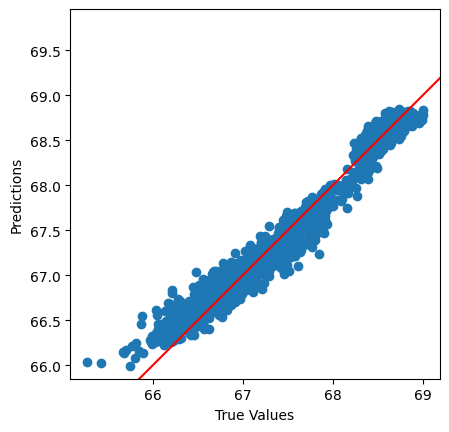

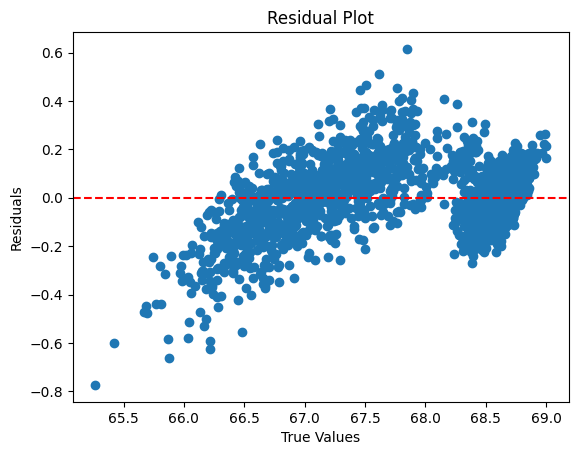

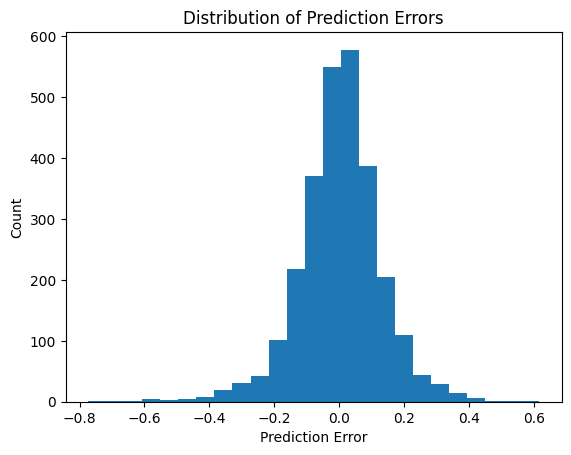

Pairwise Comparison Accuracy: 90.26%


90.25976358420456

In [21]:
#model.save('m2.h5')
def  evaluate(_model=model,_x_test=x_test,_y_test=y_test):
    # Generating predictions on your validation/test set
    predictions = _model.predict(attach_x(_x_test)).flatten()  # Adjust according to your data and model

    # Scatter plot of Actual vs Predicted values
    plt.scatter(_y_test, predictions)
    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    plt.axis('equal')
    plt.axis('square')
    plt.plot([-100, 100], [-100, 100], c="red")  # Adjust axis limits and line coordinates as per your data range
    plt.show()




    # Calculating residuals
    residuals = _y_test - predictions

    # Plotting residuals
    plt.scatter(_y_test, residuals)
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.axhline(y=0, color='red', linestyle='--')
    plt.title('Residual Plot')
    plt.show()

    # Histogram of residuals
    plt.hist(residuals, bins=25)
    plt.xlabel('Prediction Error')
    plt.ylabel('Count')
    plt.title('Distribution of Prediction Errors')
    plt.show()
    
    #def compare_all_predictions_precomputed(y_preds, y):
    correct_count = 0
    total_pairs = 0
    
    # Generate all possible pairs of indices
    for idx1, idx2 in combinations(range(len(_y_test)), 2):  
        # Get corresponding actual outputs and precomputed predictions
        y1, y2 = _y_test[idx1], _y_test[idx2]
        y1_pred, y2_pred = predictions[idx1], predictions[idx2]
        
        # Check if the model's ordering of predictions is correct
        if (y1_pred > y2_pred and y1 > y2) or (y1_pred < y2_pred and y1 < y2):
            correct_count += 1
        
        total_pairs += 1
    
    # Calculate and return accuracy
    accuracy = correct_count / total_pairs
    print(f"Pairwise Comparison Accuracy: {accuracy * 100:.2f}%")
    return accuracy*100.0

# Example Usage:
# Assume `y_preds` are your precomputed predictions
# Assume `y_test` are your actual outputs for testing data
#accuracy = compare_all_predictions_precomputed(y_preds, y_test)


model_name='best_model.h5'
model_name='m1.h5'
model_name='Yolov3.h5'
model_eval=models.load_model(model_name)
evaluate(model_eval,x_test,y_test)
#evaluate(model_eval,x_test2,y_test2)

86/86 [==============================] - 0s 817us/step


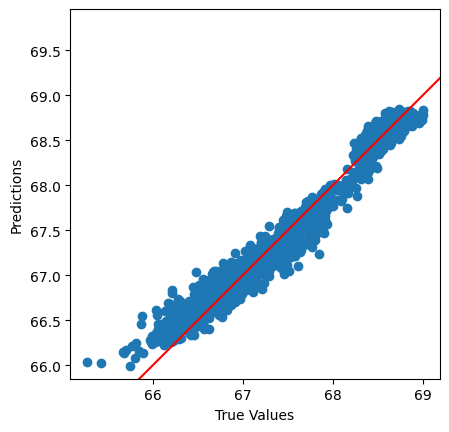

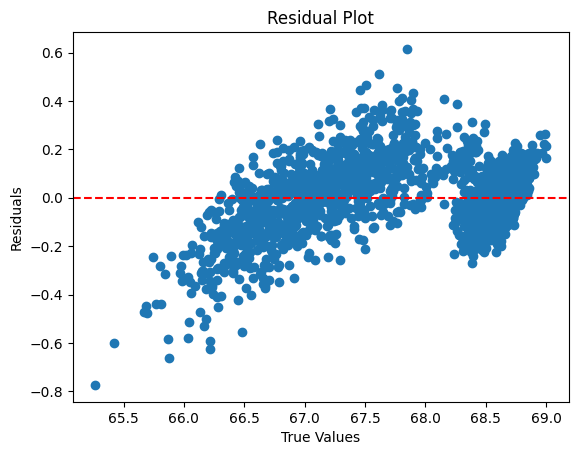

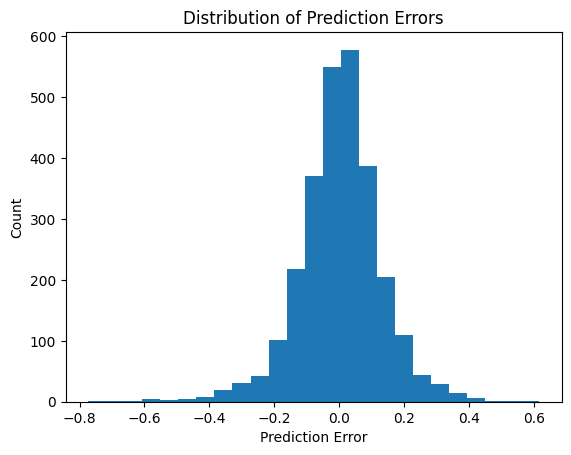

86/86 [==============================] - 0s 1ms/step - loss: 0.0166 - mean_absolute_error: 0.0941 - root_mean_squared_error: 0.1289
Validation Loss: 0.016625169664621353
Validation MAE: 0.09405560791492462
Pairwise Comparison Accuracy: 90.26%
116580/116580 [==============================] - 61s 516us/step
1) Pairwise Comparison Accuracy: 90.26%
1) Pairwise Comparison error: 9.74%
1) Pairwise Comparison Accuracy: 63.41%
1) Pairwise Comparison error: 0.35%
2) Pairwise Comparison Accuracy: 93.39%
2) Pairwise Comparison error: 6.61%
2-th) Pairwise Comparison Accuracy: 90.74%
2-th) Pairwise Comparison error: 4.53%
1,2) Pairwise Comparison Accuracy: 87.15%
1,2) Pairwise Comparison error: 3.51%
1,2_th) Pairwise Comparison Accuracy: 85.49%
1,2_th) Pairwise Comparison error: 2.55%


90.25976358420456

In [17]:
#model.save('m2.h5')
def  evaluate2(_model,_x_test=x_test,_y_test=y_test):
    # Generating predictions on your validation/test set
    predictions = _model.predict(attach_x(_x_test)).flatten()  # Adjust according to your data and model

    # Scatter plot of Actual vs Predicted values
    plt.scatter(_y_test, predictions)
    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    plt.axis('equal')
    plt.axis('square')
    plt.plot([-100, 100], [-100, 100], c="red")  # Adjust axis limits and line coordinates as per your data range
    plt.show()




    # Calculating residuals
    residuals = _y_test - predictions

    # Plotting residuals
    plt.scatter(_y_test, residuals)
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.axhline(y=0, color='red', linestyle='--')
    plt.title('Residual Plot')
    plt.show()

    # Histogram of residuals
    plt.hist(residuals, bins=25)
    plt.xlabel('Prediction Error')
    plt.ylabel('Count')
    plt.title('Distribution of Prediction Errors')
    plt.show()
    results = _model.evaluate(attach_x(_x_test), _y_test, verbose=1)

    print(f'Validation Loss: {results[0]}')
    print(f'Validation MAE: {results[1]}')
    
    #def compare_all_predictions_precomputed(y_preds, y):
    correct_count = 0
    total_pairs = 0
    
    # Generate all possible pairs of indices
    for idx1, idx2 in combinations(range(len(_y_test)), 2):  
        # Get corresponding actual outputs and precomputed predictions
        y1, y2 = _y_test[idx1], _y_test[idx2]
        y1_pred, y2_pred = predictions[idx1], predictions[idx2]
        
        # Check if the model's ordering of predictions is correct
        if (y1_pred > y2_pred and y1 > y2) or (y1_pred < y2_pred and y1 < y2):
            correct_count += 1
        
        total_pairs += 1
    
    # Calculate and return accuracy
    accuracy = correct_count / total_pairs
    print(f"Pairwise Comparison Accuracy: {accuracy * 100:.2f}%")
    
    
    _model_compare=models.load_model('m2.h5')
    
    correct_count = 0
    mis_count = 0
    
    correct_count_th = 0
    mis_count_th = 0
    
    correct_count_2 = 0
    mis_count_2 = 0
    
    correct_count_2_th = 0
    mis_count_2_th = 0
    
    correct_count_both = 0
    mis_count_both = 0
    
    correct_count_both_th = 0
    mis_count_both_th = 0
    
    
    total_pairs = 0
    
    _x_test_pairs = np.array(list(combinations(_x_test, 2)))
    cmp = _model_compare.predict(_x_test_pairs)
    
    ind=0
    for idx1, idx2 in combinations(range(len(_y_test)), 2):  
        # Get corresponding actual outputs and precomputed predictions
        y1, y2 = _y_test[idx1], _y_test[idx2]
        y1_pred, y2_pred = predictions[idx1], predictions[idx2]
        
        # first model
        if (y1_pred > y2_pred and y1 > y2 ) or (y1_pred < y2_pred and y1 < y2):
            correct_count += 1
        if (y1_pred > y2_pred and y1 < y2 ) or (y1_pred < y2_pred and y1 > y2):
            mis_count += 1
        # first model with th
        th_1=0.2
        if (y1_pred > (y2_pred+th_1) and y1 > y2 ) or (y1_pred < (y2_pred-th_1) and y1 < y2):
            correct_count_th += 1
        if (y1_pred > (y2_pred+th_1) and y1 < y2 ) or (y1_pred < (y2_pred-th_1) and y1 > y2):
            mis_count_th += 1
        
        # second model
        p=cmp[ind].argmax()
        if (p==2 and y1 > y2 ) or (p==0 and y1 < y2):
            correct_count_2 += 1
        if (p==2 and y1 < y2 ) or (p==0 and y1 > y2):
            mis_count_2 += 1
        # second model with th
        th_2=0.8    
        if (cmp[ind][2]>th_2 and y1 > y2 ) or (cmp[ind][0]>th_2 and y1 < y2):
            correct_count_2_th += 1
        if (cmp[ind][2]>th_2 and y1 < y2 ) or (cmp[ind][0]>th_2 and y1 > y2):
            mis_count_2_th += 1
        
        # both model 
        if (y1_pred > y2_pred and p==2 and y1 > y2 ) or (y1_pred < y2_pred and p==0 and y1 < y2):
            correct_count_both += 1
        if (y1_pred > y2_pred and p==2 and y1 < y2 ) or (y1_pred < y2_pred and p==0 and y1 > y2):
            mis_count_both += 1
        # both model with th
        th=0.8
        if (y1_pred > y2_pred and cmp[ind][2]>th and y1 > y2 ) or (y1_pred < y2_pred and cmp[ind][0]>th and y1 < y2):
            correct_count_both_th += 1
        if (y1_pred > y2_pred and cmp[ind][2]>th and y1 < y2 ) or (y1_pred < y2_pred and cmp[ind][0]>th and y1 > y2):
            mis_count_both_th += 1
        
        ind=ind+1
        total_pairs += 1
    
    # Calculate and return accuracy first model(regression)
    accuracy = (correct_count) / total_pairs
    error = (mis_count) / total_pairs
    print(f"1) Pairwise Comparison Accuracy: {accuracy * 100:.2f}%")
    print(f"1) Pairwise Comparison error: {error * 100:.2f}%")
    
    # Calculate and return accuracy first model(regression) with th
    accuracy_th = (correct_count_th) / total_pairs
    error_th = (mis_count_th) / total_pairs
    print(f"1) Pairwise Comparison Accuracy: {accuracy_th * 100:.2f}%")
    print(f"1) Pairwise Comparison error: {error_th * 100:.2f}%")
    
    # Calculate and return accuracy second model(comparison)
    accuracy_2 = (correct_count_2) / total_pairs
    error_2 = (mis_count_2) / total_pairs
    print(f"2) Pairwise Comparison Accuracy: {accuracy_2 * 100:.2f}%")
    print(f"2) Pairwise Comparison error: {error_2 * 100:.2f}%")
    
    # Calculate and return accuracy seond model with th
    accuracy_2_th = (correct_count_2_th) / total_pairs
    error_2_th = (mis_count_2_th) / total_pairs
    print(f"2-th) Pairwise Comparison Accuracy: {accuracy_2_th * 100:.2f}%")
    print(f"2-th) Pairwise Comparison error: {error_2_th * 100:.2f}%")
    
    # Calculate and return accuracy both model
    accuracy_both = (correct_count_both) / total_pairs
    error_both = (mis_count_both) / total_pairs
    print(f"1,2) Pairwise Comparison Accuracy: {accuracy_both * 100:.2f}%")
    print(f"1,2) Pairwise Comparison error: {error_both * 100:.2f}%")
    
    # Calculate and return accuracy both model with th
    accuracy_both_th = (correct_count_both_th) / total_pairs
    error_both_th = (mis_count_both_th) / total_pairs
    print(f"1,2_th) Pairwise Comparison Accuracy: {accuracy_both_th * 100:.2f}%")
    print(f"1,2_th) Pairwise Comparison error: {error_both_th * 100:.2f}%")
    
    return accuracy*100.0

# Example Usage:
# Assume `y_preds` are your precomputed predictions
# Assume `y_test` are your actual outputs for testing data
#accuracy = compare_all_predictions_precomputed(y_preds, y_test)


model_name='best_model.h5'
model_name='m1.h5'
model_eval=models.load_model(model_name)
evaluate2(model_eval,x_test,y_test)
#evaluate(model_eval,x_test2,y_test2)

In [18]:
model1=models.load_model('m1.h5')
model1.summary()
model2=models.load_model('m2.h5')
model2.sumamry()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 5700)              0         
                                                                 
 dense (Dense)               (None, 128)               729728    
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 8)                 520       
                                                                 
 dense_3 (Dense)             (None, 1)                 9         
                                                                 
Total params: 738513 (2.82 MB)
Trainable params: 738513 (2.82 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


AttributeError: 'Sequential' object has no attribute 'sumamry'

In [ ]:
def pairwise_data_generator2(x, y, batch_size):
    num_samples = len(x)
    pair_indices = list(combinations(range(num_samples), 2))
    
    while True:  # Loop forever, the generator never ends
        # Shuffle indices to minimize overfitting
        np.random.shuffle(pair_indices)
        
        for i in range(0, len(pair_indices), batch_size):
            if i+batch_size > len(pair_indices)-1 :
                break
            batch_pairs = pair_indices[i:i+batch_size]
            x_batch = np.array([[x[idx1], x[idx2]] for idx1, idx2 in batch_pairs])
            y_batch = np.array([np.sign(y[idx1] - y[idx2]) for idx1, idx2 in batch_pairs])
            
            y_batch_encoded = np.zeros((len(y_batch), 3))
            y_batch_encoded[y_batch == -1, 0] = 1
            y_batch_encoded[y_batch == 0, 1] = 1
            y_batch_encoded[y_batch == 1, 2] = 1
            #print(f'y:{y_batch_encoded[0]},shape:{x_batch.shape}, {y_batch.shape}')
            #input('ddd')
            
            yield x_batch, y_batch_encoded


def pairwise_data_generator(x, y, batch_size):
    num_samples = len(x)
    
    while True:
        # Sample pair indices instead of generating all possible pairs
        batch_pairs = [(random.randint(0, num_samples-1), random.randint(0, num_samples-1)) for _ in range(batch_size)]
        
        x_batch = np.array([[x[idx1], x[idx2]] for idx1, idx2 in batch_pairs])
        y_batch = np.array([np.sign(y[idx1] - y[idx2]) for idx1, idx2 in batch_pairs])
        # one-hot encoding
        y_batch_encoded = np.zeros((len(y_batch), 3))
        y_batch_encoded[y_batch == -1, 0] = 1
        y_batch_encoded[y_batch == 0, 1] = 1
        y_batch_encoded[y_batch == 1, 2] = 1
        #print(f'y:{y_batch_encoded[0]},shape:{x_batch.shape}, {y_batch.shape}')
        #input('ddd')
        yield x_batch, y_batch_encoded
        
        
def create_pairwise_model(input_shape):
    model = models.Sequential([
        layers.InputLayer(input_shape=input_shape),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(8, activation='relu'),
        #layers.Dense(1, activation='sigmoid')
        layers.Dense(3,'softmax')
    ])

    model.compile(optimizer='adam',
                  #loss='binary_crossentropy',
                  loss='categorical_crossentropy',  # Suitable loss for multi-class classification'
                  #loss='sparse_categorical_crossentropy', # if you do not want to do one hot decoding for labels;using (-1,0,1)
                  metrics=['accuracy'])
    return model

# Define your input shape according to concatenated_matrix
input_shape = (2, 75)  # Example shape, adjust accordingly
pairwise_model = create_pairwise_model(input_shape)



batch_size = 64  # Choose an appropriate batch size
#pairwise_generator = pairwise_data_generator(x_train, y_train, batch_size)
# Define two different generators for training and validation
train_generator = pairwise_data_generator(x_train, y_train, batch_size)
val_generator = pairwise_data_generator(x_test, y_test, batch_size)
train_steps = len(list(combinations(range(len(x_train)), 2))) // batch_size
val_steps = len(list(combinations(range(len(x_test)), 2))) // batch_size





best_model_filepath_acc = 'best_compare_model.h5'  # Filepath to save the best model
model_checkpoint_acc = ModelCheckpoint(filepath=best_model_filepath_acc, monitor='val_accuracy', save_best_only=True, verbose=1)

class BestMetricLogger_acc(Callback):
    def __init__(self, monitor='val_accuracy', additional_monitor='val_loss', mode='max'):
        super(BestMetricLogger_acc, self).__init__()
        self.monitor = monitor
        self.additional_monitor = additional_monitor
        self.best_value = np.inf if mode == 'min' else -np.inf
        self.best_additional_value = np.inf if mode == 'min' else -np.inf
        self.best_epoch = 0
        self.mode = mode

    def on_epoch_end(self, epoch, logs=None):
        current_value = logs.get(self.monitor)
        if self.mode == 'min' and current_value < self.best_value:
            self.best_value = current_value
            self.best_additional_value = logs.get(self.additional_monitor)
            self.best_epoch = epoch
        elif self.mode == 'max' and current_value > self.best_value:
            self.best_value = current_value
            self.best_additional_value = logs.get(self.additional_monitor)
            self.best_epoch = epoch
        print(f' - best_{self.monitor}: {self.best_value:.4f} at epoch {self.best_epoch} {self.additional_monitor}: {self.best_additional_value:.4f}')
        print('****************************\n\n')

# Example usage:
best_metric_logger_acc = BestMetricLogger_acc(monitor='val_accuracy', mode='max', additional_monitor='val_loss')

early_stopping_acc = EarlyStopping(
    monitor='val_accuracy',  # Which metric to monitor
    patience=100,  # Number of epochs with no improvement to wait before stopping
    verbose=1,  # To log information
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity.
)
# Then train using the two generators
history = pairwise_model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    validation_data=val_generator,
    validation_steps=val_steps,
    epochs=1000,
    callbacks=[model_checkpoint_acc, best_metric_logger_acc, early_stopping_acc]
)


In [ ]:
def predict(model_name,x):
    model=models.load_model(model_name)
    prediction = model.predict(attach_x(x)).flatten()  # Adjust according to your data and model
    return prediction
Acc=predict(model_name='m1.h5',x=np.full((1,75),0))
Acc